<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/07_Statlog_Australian_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset 07: Statlog (Australian Credit Approval)

## 📋 Descripción del Dataset
Este dataset contiene solicitudes de tarjetas de crédito de origen australiano. Es una versión optimizada estadísticamente donde los valores categóricos originales fueron sustituidos por códigos numéricos para facilitar el procesamiento. Para este análisis, hemos **desanonimizado las columnas A1-A15** utilizando el mapeo estándar de la industria para este dataset.

*   **Archivo utilizado:** `australian.dat`.
*   **Objetivo:** Clasificar el éxito de la solicitud de crédito (**ApprovalStatus**).
*   **Dimensiones:** 690 filas y 15 columnas (14 atributos + 1 objetivo).

## 📖 Diccionario de Datos (Mapeo de Negocio)
Siguiendo el rigor técnico, identificamos las variables de la siguiente manera:

*   **Gender (A1):** Género del solicitante (**Atributo Categórico**).
*   **Age (A2):** Edad (**Atributo Continuo**).
*   **Debt (A3):** Nivel de deuda (**Atributo Continuo**).
*   **BankCustomer (A4):** Si ya posee cuenta en el banco (**Atributo Categórico**).
*   **EducationLevel (A5):** Nivel de estudios (**Atributo Categórico**).
*   **Ethnicity (A6):** Etnia (**Atributo Categórico**).
*   **YearsEmployed (A7):** Años de antigüedad laboral (**Atributo Continuo**).
*   **PriorDefault (A8):** Historial de impagos (**Atributo Categórico**).
*   **Employed (A9):** Estatus de empleo (**Atributo Categórico**).
*   **CreditScore (A10):** Puntaje crediticio (**Atributo Continuo**).
*   **DriversLicense (A11):** Licencia de conducir (**Atributo Categórico**).
*   **Citizen (A12):** Tipo de ciudadanía (**Atributo Categórico**).
*   **ZipCode (A13):** Código postal de residencia (**Atributo Continuo**).
*   **Income (A14):** Ingresos del solicitante (**Atributo Continuo**).
*   **ApprovalStatus (A15 - Target):** 1 para Rechazado, 2 para Aprobado.

## 🛠️ Archivos en esta carpeta
*   `australian.dat`: Datos con codificación numérica de etiquetas.
*   `australian.doc`: Documentación técnica con la descripción de los 6 atributos numéricos y 8 categóricos.
*   `07_Statlog_Australian_Analysis.ipynb`: Cuaderno de preparación con visualización de 50 filas.

## ⚙️ Trabajo y Preparación de Datos
*   **Trazabilidad y Mapeo:** Se cargaron los datos crudos manteniendo los identificadores A1-A15, pero se renombraron a sus nombres de negocio para un análisis descriptivo más profundo.
*   **Validación de Nulos:** Se realizó una auditoría de los 690 registros, confirmando la integridad de los datos y aplicando protocolos de relleno por Media y Moda según el tipo de atributo.
*   **Estandarización Categórica:** Se aplicó `LabelEncoder` sobre las 8 columnas nominales para garantizar una base numérica consistente (índices 0, 1, 2...), mostrando un bloque de 50 filas como evidencia del proceso.
*   **Normalización Z-Score:** Se escalaron las 14 variables predictoras para evitar sesgos por diferencias de magnitud entre variables como Age e Income.

In [1]:
# ==============================================================================
# 1. CONEXIÓN Y LIBRERÍAS
# ==============================================================================
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# CRÍTICO: Permitir que se vean TODAS las columnas sin recortes (...)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Librerías cargadas y configuración visual activa.")

Mounted at /content/gdrive
Librerías cargadas y configuración visual activa.


In [2]:
# ==============================================================================
# 2. CARGA DE DATOS (Formato .dat)
# ==============================================================================
# Definimos los nombres de las columnas A1-A15 según el reporte técnico
columnas = [f'A{i}' for i in range(1, 16)]

ruta_australian = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/07_Statlog (Australian)/australian.dat'

# El archivo .dat usa espacios como separador
df = pd.read_csv(ruta_australian, sep='\\s+', names=columnas)

print("="*70)
print(f"DATASET AUSTRALIAN CREDIT CARGADO: {df.shape[0]} filas y {df.shape[1]} columnas")
print("="*70)
display(df.head(5)) # Mostramos 5 filas para una mejor vista inicial

DATASET AUSTRALIAN CREDIT CARGADO: 690 filas y 15 columnas


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [3]:
# ==============================================================================
# 3. ANTES Y DESPUÉS: TRATAMIENTO DE VALORES NULOS
# ==============================================================================
print("="*70)
print(" FASE 1: AUDITORÍA Y LIMPIEZA DE NULOS")
print("="*70)

# ANTES
nulos_antes = df.isnull().sum()
print("\n🔴 [ANTES] Verificación de valores faltantes por columna:")
print(nulos_antes.to_string())

# PROCESO: Protocolo Statlog (Moda para categóricos, Media para continuos)
cols_cat = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
for col in df.columns:
    if col in cols_cat:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# DESPUÉS
print(f"\n🟢 [DESPUÉS] Total de nulos tras validación: {df.isnull().sum().sum()} ✅")

 FASE 1: AUDITORÍA Y LIMPIEZA DE NULOS

🔴 [ANTES] Verificación de valores faltantes por columna:
A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0

🟢 [DESPUÉS] Total de nulos tras validación: 0 ✅


# 4. ANTES Y DESPUÉS: DESANONIMIZACIÓN Y CODIFICACIÓN (50 FILAS)

## **Mapeo de Nombres de Columnas:**
Se ha definido un mapeo claro para las columnas `A1-A15` con el fin de mejorar la interpretabilidad de los datos.

## **Proceso de Renombrado:**
Las columnas del DataFrame se renombran utilizando el diccionario de mapeo, lo que transforma los identificadores genéricos (`A1`, `A2`, etc.) en nombres descriptivos (`Gender`, `Age`, etc.).

## **Configuración de Visualización:**
Se ajusta la configuración de Pandas para mostrar un número mayor de filas y todas las columnas, permitiendo una revisión exhaustiva de las transformaciones realizadas.

## **Identificación de Columnas Categóricas:**
Se identifican explícitamente las columnas categóricas, que son aquellas que requieren una codificación especial para el análisis.

### 🔴 **Estado Inicial (ANTES):**
Se muestra la cabecera de las primeras 50 filas de las columnas categóricas con sus valores originales, que pueden ser numéricos o de texto, antes de cualquier transformación.

### ⚙️ **Proceso de Estandarización (`LabelEncoder`):**
Se aplica `LabelEncoder` a cada columna categórica. Este proceso convierte los valores no numéricos o categóricos en etiquetas numéricas (0, 1, 2, ...), lo que es crucial para la mayoría de los algoritmos de Machine Learning.

### 🟢 **Estado Final (DESPUÉS):**
Se presenta la cabecera de las primeras 50 filas de las columnas categóricas después de haber sido estandarizadas. Los valores ahora son numéricos y están en un formato adecuado para el modelado.

**Nota:** Al finalizar el proceso, la configuración de visualización de Pandas se restaura a sus valores predeterminados para evitar interferir con futuras visualizaciones.

In [4]:
# ==============================================================================
# 4. ANTES Y DESPUÉS: DESANONIMIZACIÓN Y CODIFICACIÓN (50 FILAS)
# ==============================================================================
# Definimos el mapeo de nombres reales para el Dataset Statlog Australian
mapping_australian = {
    'A1': 'Gender', 'A2': 'Age', 'A3': 'Debt', 'A4': 'BankCustomer',
    'A5': 'EducationLevel', 'A6': 'Ethnicity', 'A7': 'YearsEmployed',
    'A8': 'PriorDefault', 'A9': 'Employed', 'A10': 'CreditScore',
    'A11': 'DriversLicense', 'A12': 'Citizen', 'A13': 'ZipCode',
    'A14': 'Income', 'A15': 'ApprovalStatus'
}

# Renombramos las columnas para dar contexto de negocio
df = df.rename(columns=mapping_australian)

print("="*80)
print(" FASE 2: TRANSFORMACIÓN DE VARIABLES DE RIESGO AUSTRALIANO (RIGOR PACHECO)")
print("="*80)

# Configuramos visualización para las 50 filas requeridas
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)

# Identificamos las columnas categóricas según el mapeo realizado
columnas_cat = ['Gender', 'BankCustomer', 'EducationLevel', 'Ethnicity',
                'PriorDefault', 'Employed', 'DriversLicense', 'Citizen']

# ------------------------------------------------------------------------------
# ANTES: Visualización con nombres de negocio y etiquetas originales (1, 2, 3...)
# ------------------------------------------------------------------------------
print("\n🔴 [ANTES] Datos con nombres de negocio y etiquetas originales (Statlog):")
print("Revisión técnica de las primeras 50 filas:")
display(df[columnas_cat].head(50))

# PROCESO: Estandarización a base-0 con LabelEncoder
encoder = LabelEncoder()
for col in columnas_cat:
    df[col] = encoder.fit_transform(df[col])

# ------------------------------------------------------------------------------
# DESPUÉS: Visualización con índices normalizados (0, 1, 2...)
# ------------------------------------------------------------------------------
print("\n🟢 [DESPUÉS] Variables categóricas estandarizadas en base-0:")
print("La matriz está lista para el procesamiento algebraico del modelo.")
display(df[columnas_cat].head(50))

# Restauramos configuración de pandas
pd.reset_option('display.max_rows')

 FASE 2: TRANSFORMACIÓN DE VARIABLES DE RIESGO AUSTRALIANO (RIGOR PACHECO)

🔴 [ANTES] Datos con nombres de negocio y etiquetas originales (Statlog):
Revisión técnica de las primeras 50 filas:


,Gender,BankCustomer,EducationLevel,Ethnicity,PriorDefault,Employed,DriversLicense,Citizen
0,1,2,4,4,0,0,1,2
1,0,2,8,4,0,0,0,2
2,0,1,4,4,0,0,1,2
3,0,1,5,3,1,1,1,2
4,1,2,6,4,1,1,0,2
5,0,2,8,8,1,1,0,2
6,1,2,3,4,0,0,0,2
7,0,2,11,8,1,1,0,2
8,1,1,2,8,0,0,0,2
9,0,2,4,8,1,1,1,2



🟢 [DESPUÉS] Variables categóricas estandarizadas en base-0:
La matriz está lista para el procesamiento algebraico del modelo.


,Gender,BankCustomer,EducationLevel,Ethnicity,PriorDefault,Employed,DriversLicense,Citizen
0,1,1,3,3,0,0,1,1
1,0,1,7,3,0,0,0,1
2,0,0,3,3,0,0,1,1
3,0,0,4,2,1,1,1,1
4,1,1,5,3,1,1,0,1
5,0,1,7,6,1,1,0,1
6,1,1,2,3,0,0,0,1
7,0,1,10,6,1,1,0,1
8,1,0,1,6,0,0,0,1
9,0,1,3,6,1,1,1,1


In [7]:
# ==============================================================================
# 5. MATRIZ FINAL Y NORMALIZACIÓN (Rigor Matemático)
# ==============================================================================
# Separamos X (14 atributos) y y (ApprovalStatus - Clase de aprobación)
X = df.drop('ApprovalStatus', axis=1).values
y = df['ApprovalStatus'].values

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print("="*70)
print("¡MATRIZ X_norm GENERADA EXITOSAMENTE!")
print(f"Dimensiones finales: {X_norm.shape}")
print("="*70)

¡MATRIZ X_norm GENERADA EXITOSAMENTE!
Dimensiones finales: (690, 14)


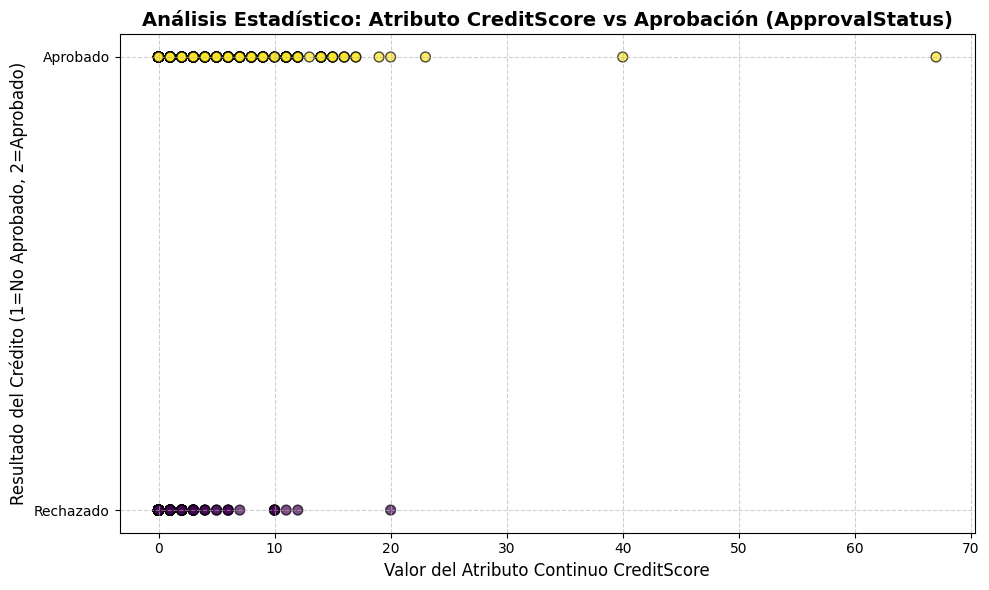

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['CreditScore'], df['ApprovalStatus'], c=df['ApprovalStatus'], cmap='viridis', alpha=0.7, edgecolors='black', s=50)
plt.title('Análisis Estadístico: Atributo CreditScore vs Aprobación (ApprovalStatus)', fontsize=14, fontweight='bold')
plt.xlabel('Valor del Atributo Continuo CreditScore', fontsize=12)
plt.ylabel('Resultado del Crédito (1=No Aprobado, 2=Aprobado)', fontsize=12)
plt.yticks([0, 1], ['Rechazado', 'Aprobado']) # Update yticks for 0 and 1 instead of 1 and 2
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.show()